# 🏀 NBA GAMES.CSV - KAPSAMLI MAÇ ANALİZİ

Bu notebook, **games.csv** dosyasını wget ile indirir ve çok detaylı analizler yapar.

## Dataset İçeriği
- **Tarih:** 2004-2020 arası tüm NBA maçları
- **Maç Bilgileri:** Ev sahibi, deplasman takımları
- **Skorlar:** Maç sonuçları, sayılar
- **İstatistikler:** FG%, 3P%, FT%, rebounds, assists, steals, blocks, turnovers

## Analiz Kapsamı
1. Veri indirme ve yükleme
2. Temel keşifsel analiz
3. Eksik veri analizi
4. Zaman serisi analizleri
5. Skor ve performans analizleri
6. Ev sahibi avantajı analizi
7. Şut verimliliği analizleri
8. Takım bazlı istatistikler
9. Sezon trendleri
10. Korelasyon analizleri
11. İleri düzey içgörüler

## 📦 Kütüphane Kurulumu ve Import

In [1]:
# Gerekli kütüphaneler
import os
import subprocess
import zipfile
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Kütüphaneler başarıyla yüklendi!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'📈 NumPy version: {np.__version__}')

✅ Kütüphaneler başarıyla yüklendi!
📊 Pandas version: 2.2.2
📈 NumPy version: 2.0.2


## 📥 Dataset İndirme (Wget ile Kaggle)

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"🔽 {zip_filename} indiriliyor...")
    print(f"📍 URL: {download_url}")
    print(f"{'='*70}")
    print("⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ İndirme başarılı: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"🗑️ Zip silindi (disk alanı tasarrufu)")

        print(f"\n✅ Dataset hazır: {dest_folder}")
        return True
    except Exception as e:
        print(f"❌ Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "nba_games_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# NBA Games dataset bilgileri
dataset_info = {
    "name": "nba-games",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games",
    "folder": dataset_folder,
    "zip_filename": "nba-games.zip"
}

# games.csv var mı kontrol et
games_path = os.path.join(dataset_folder, "games.csv")
if os.path.exists(games_path):
    print("\n" + "="*70)
    print("✅ Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("🏀 NBA GAMES DATASET İNDİRİLİYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("❌ MANUEL İNDİRME GEREKLİ")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/nathanlauga/nba-games")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. Zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu hücreyi tekrar çalıştırın")


🏀 NBA GAMES DATASET İNDİRİLİYOR

🔽 nba-games.zip indiriliyor...
📍 URL: https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games
⏳ Bu işlem birkaç dakika sürebilir...


✅ İndirme başarılı: nba_games_dataset/nba-games.zip

📦 Açılıyor: nba_games_dataset/nba-games.zip
🗑️ Zip silindi (disk alanı tasarrufu)

✅ Dataset hazır: nba_games_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("📂 DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  📄 {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("❌ CSV dosyaları bulunamadı!")


📂 DATASET DOSYALARI
  📄 games.csv                      -     3.92 MB
  📄 games_details.csv              -    88.77 MB
  📄 players.csv                    -     0.25 MB
  📄 ranking.csv                    -    14.73 MB
  📄 teams.csv                      -     0.00 MB


## 📊 GAMES.CSV - Veri Yükleme ve İlk Bakış

In [5]:
# games.csv dosyasını yükle
games_file = os.path.join(dataset_folder, "games.csv")
df = pd.read_csv(games_file)

print("="*70)
print("🏀 GAMES.CSV - TEMEL BİLGİLER")
print("="*70)
print(f"\n📌 Toplam Maç Sayısı: {len(df):,}")
print(f"📌 Sütun Sayısı: {len(df.columns)}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📋 Veri Şekli (shape): {df.shape}")
print("="*70)

🏀 GAMES.CSV - TEMEL BİLGİLER

📌 Toplam Maç Sayısı: 26,651
📌 Sütun Sayısı: 21
📌 Bellek Kullanımı: 6.74 MB

📋 Veri Şekli (shape): (26651, 21)


In [6]:
# İlk 10 kayıt
print("\n📋 İLK 10 MAÇ KAYDI:")
print("="*70)
df.head(10)


📋 İLK 10 MAÇ KAYDI:


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.000,0.484,0.926,0.382,25.000,46.000,1610612759,117.000,0.478,0.815,0.321,23.000,44.000,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.000,0.488,0.952,0.457,16.000,40.000,1610612764,112.000,0.561,0.765,0.333,20.000,37.000,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.000,0.482,0.786,0.313,22.000,37.000,1610612749,106.000,0.470,0.682,0.433,20.000,46.000,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.000,0.441,0.909,0.297,27.000,49.000,1610612765,93.000,0.392,0.735,0.261,15.000,46.000,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.000,0.429,1.000,0.378,22.000,47.000,1610612741,110.000,0.500,0.773,0.292,20.000,47.000,0
5,2022-12-21,22200469,Final,1610612738,1610612754,2022,1610612738,112.000,0.386,0.840,0.317,26.000,62.000,1610612754,117.000,0.469,0.778,0.462,27.000,47.000,0
6,2022-12-21,22200470,Final,1610612751,1610612744,2022,1610612751,143.000,0.643,0.875,0.636,42.000,32.000,1610612744,113.000,0.494,0.760,0.364,32.000,36.000,1
7,2022-12-21,22200471,Final,1610612752,1610612761,2022,1610612752,106.000,0.553,0.611,0.423,25.000,38.000,1610612761,113.000,0.447,0.909,0.265,17.000,38.000,0
8,2022-12-21,22200472,Final,1610612745,1610612753,2022,1610612745,110.000,0.466,0.647,0.395,22.000,49.000,1610612753,116.000,0.451,0.697,0.297,19.000,45.000,0
9,2022-12-21,22200473,Final,1610612750,1610612742,2022,1610612750,99.000,0.494,0.700,0.267,23.000,39.000,1610612742,104.000,0.453,0.852,0.333,17.000,39.000,0


In [7]:
# Son 10 kayıt
print("\n📋 SON 10 MAÇ KAYDI:")
print("="*70)
df.tail(10)


📋 SON 10 MAÇ KAYDI:


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
26641,2014-10-07,11400014,Final,1610612742,1610612745,2014,1610612742,108.000,0.406,0.734,0.321,14.000,40.000,1610612745,111.000,0.462,0.644,0.385,19.000,40.000,0
26642,2014-10-07,11400009,Final,1610612762,1610612757,2014,1610612762,92.000,0.442,0.567,0.500,15.000,52.000,1610612757,73.000,0.346,0.700,0.158,13.000,45.000,1
26643,2014-10-07,11400010,Final,1610612758,1610612761,2014,1610612758,113.000,0.552,0.700,0.364,20.000,42.000,1610612761,106.000,0.488,0.500,0.417,24.000,32.000,1
26644,2014-10-07,11400015,Final,1610612746,1610612744,2014,1610612746,94.000,0.407,0.710,0.261,22.000,37.000,1610612744,112.000,0.486,0.766,0.316,25.000,44.000,0
26645,2014-10-06,11400006,Final,1610612738,1610612755,2014,1610612738,98.000,0.341,0.730,0.333,17.000,52.000,1610612755,78.000,0.403,0.423,0.357,14.000,51.000,1
26646,2014-10-06,11400007,Final,1610612737,1610612740,2014,1610612737,93.000,0.419,0.821,0.421,24.000,50.000,1610612740,87.000,0.366,0.643,0.375,17.000,43.000,1
26647,2014-10-06,11400004,Final,1610612741,1610612764,2014,1610612741,81.000,0.338,0.719,0.381,18.000,40.000,1610612764,85.000,0.411,0.636,0.267,17.000,47.000,0
26648,2014-10-06,11400005,Final,1610612747,1610612743,2014,1610612747,98.000,0.448,0.682,0.500,29.000,45.000,1610612743,95.000,0.387,0.659,0.500,19.000,43.000,1
26649,2014-10-05,11400002,Final,1610612761,1610612758,2014,1610612761,99.000,0.440,0.771,0.333,21.000,30.000,1610612758,94.000,0.469,0.725,0.385,18.000,45.000,1
26650,2014-10-04,11400001,Final,1610612748,1610612740,2014,1610612748,86.000,0.431,0.679,0.333,18.000,42.000,1610612740,98.000,0.462,0.706,0.438,19.000,42.000,0


In [8]:
# Sütun tipleri ve bilgileri
print("\n" + "="*70)
print("📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ")
print("="*70)
df.info()


📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26651 entries, 0 to 26650
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GAME_DATE_EST     26651 non-null  object 
 1   GAME_ID           26651 non-null  int64  
 2   GAME_STATUS_TEXT  26651 non-null  object 
 3   HOME_TEAM_ID      26651 non-null  int64  
 4   VISITOR_TEAM_ID   26651 non-null  int64  
 5   SEASON            26651 non-null  int64  
 6   TEAM_ID_home      26651 non-null  int64  
 7   PTS_home          26552 non-null  float64
 8   FG_PCT_home       26552 non-null  float64
 9   FT_PCT_home       26552 non-null  float64
 10  FG3_PCT_home      26552 non-null  float64
 11  AST_home          26552 non-null  float64
 12  REB_home          26552 non-null  float64
 13  TEAM_ID_away      26651 non-null  int64  
 14  PTS_away          26552 non-null  float64
 15  FG_PCT_away       26552 non-null  float64
 16  FT_PC

In [9]:
# Tüm sütun isimleri
print("\n" + "="*70)
print(f"📝 TÜM SÜTUNLAR ({len(df.columns)} adet)")
print("="*70)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


📝 TÜM SÜTUNLAR (21 adet)
 1. GAME_DATE_EST
 2. GAME_ID
 3. GAME_STATUS_TEXT
 4. HOME_TEAM_ID
 5. VISITOR_TEAM_ID
 6. SEASON
 7. TEAM_ID_home
 8. PTS_home
 9. FG_PCT_home
10. FT_PCT_home
11. FG3_PCT_home
12. AST_home
13. REB_home
14. TEAM_ID_away
15. PTS_away
16. FG_PCT_away
17. FT_PCT_away
18. FG3_PCT_away
19. AST_away
20. REB_away
21. HOME_TEAM_WINS


In [10]:
# İstatistiksel özet (sayısal sütunlar)
print("\n" + "="*70)
print("📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)")
print("="*70)
df.describe().T


📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)


,count,mean,std,min,25%,50%,75%,max
GAME_ID,26651.000,21754866.961,5570189.474,10300001.000,20700010.500,21200763.000,21800046.500,52100211.000
HOME_TEAM_ID,26651.000,1610612751.368,8.639,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
VISITOR_TEAM_ID,26651.000,1610612751.408,8.659,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
SEASON,26651.000,2012.114,5.587,2003.000,2007.000,2012.000,2017.000,2022.000
TEAM_ID_home,26651.000,1610612751.368,8.639,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
PTS_home,26552.000,103.456,13.283,36.000,94.000,103.000,112.000,168.000
FG_PCT_home,26552.000,0.461,0.057,0.250,0.422,0.460,0.500,0.684
FT_PCT_home,26552.000,0.760,0.101,0.143,0.697,0.765,0.833,1.000
FG3_PCT_home,26552.000,0.356,0.111,0.000,0.286,0.357,0.429,1.000
AST_home,26552.000,22.823,5.193,6.000,19.000,23.000,26.000,50.000


In [11]:
# Kategorik sütunlar için özet
print("\n" + "="*70)
print("📋 KATEGORİK SÜTUNLAR ÖZETİ")
print("="*70)
df.describe(include=['object']).T


📋 KATEGORİK SÜTUNLAR ÖZETİ


,count,unique,top,freq
GAME_DATE_EST,26651,4304,2020-12-23,16
GAME_STATUS_TEXT,26651,1,Final,26651


## 🔍 Eksik Veri Analizi

In [12]:
# Detaylı eksik veri analizi
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Sütun': missing_data.index,
    'Eksik_Sayı': missing_data.values,
    'Eksik_Yüzde': missing_pct.values
}).sort_values('Eksik_Sayı', ascending=False)

print("="*70)
print("⚠️ EKSİK VERİ ANALİZİ")
print("="*70)

missing_cols = missing_df[missing_df['Eksik_Sayı'] > 0]
if len(missing_cols) > 0:
    print(f"\n❗ {len(missing_cols)} sütunda eksik veri var:\n")
    print(missing_cols.to_string(index=False))
    print(f"\n📊 Toplam eksik hücre: {missing_cols['Eksik_Sayı'].sum():,}")
    print(f"📊 Genel eksiklik oranı: {(missing_cols['Eksik_Sayı'].sum() / (len(df) * len(df.columns)) * 100):.2f}%")
else:
    print("\n✅ MÜKEM MEL! Hiç eksik veri yok.")
    print("Veri seti temiz ve eksiksiz.")

⚠️ EKSİK VERİ ANALİZİ

❗ 12 sütunda eksik veri var:

       Sütun  Eksik_Sayı  Eksik_Yüzde
    AST_home          99        0.371
 FT_PCT_home          99        0.371
FG3_PCT_home          99        0.371
    PTS_home          99        0.371
 FG_PCT_home          99        0.371
    REB_away          99        0.371
    AST_away          99        0.371
 FT_PCT_away          99        0.371
FG3_PCT_away          99        0.371
 FG_PCT_away          99        0.371
    REB_home          99        0.371
    PTS_away          99        0.371

📊 Toplam eksik hücre: 1,188
📊 Genel eksiklik oranı: 0.21%


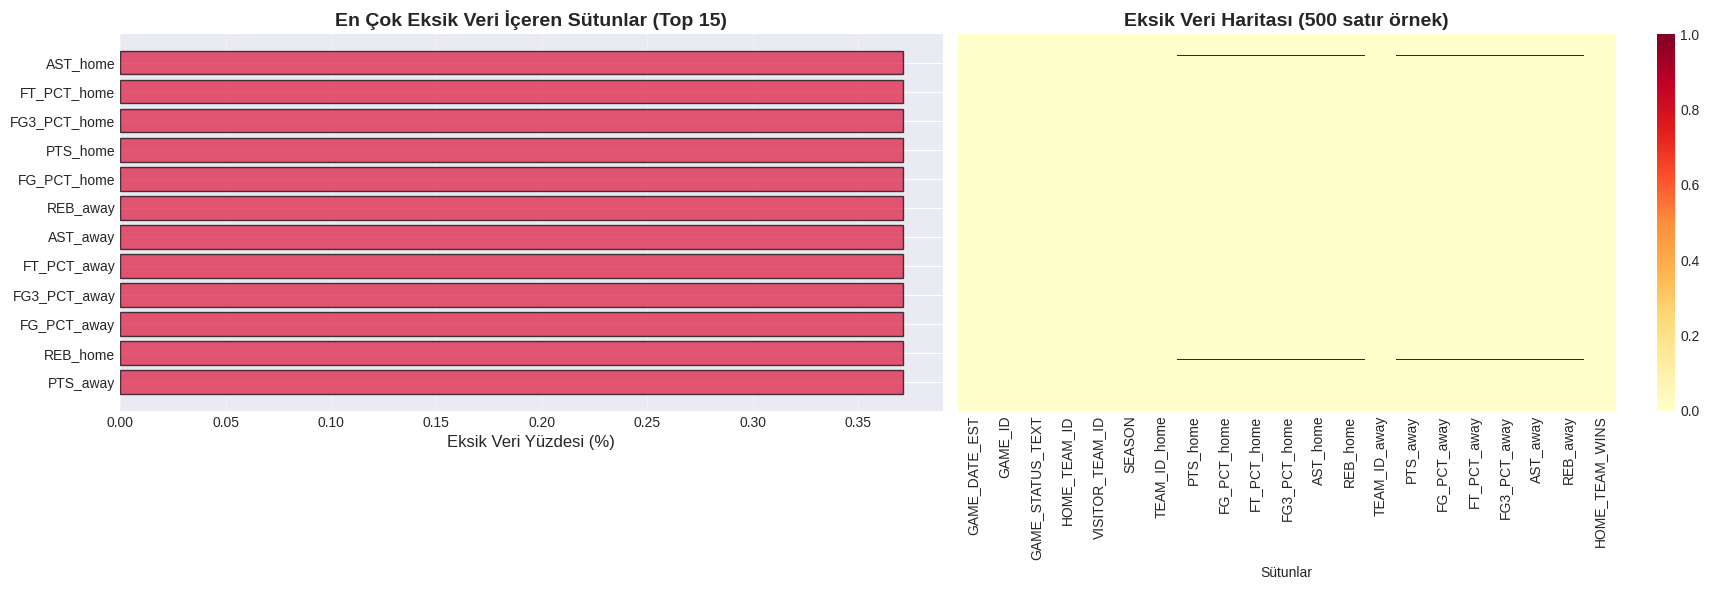

In [13]:
# Eksik veri görselleştirmesi
if len(missing_cols) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Bar plot - en çok eksik olan 15 sütun
    top_missing = missing_cols.head(15)
    axes[0].barh(range(len(top_missing)), top_missing['Eksik_Yüzde'],
                color='crimson', edgecolor='black', alpha=0.7)
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Sütun'])
    axes[0].set_xlabel('Eksik Veri Yüzdesi (%)', fontsize=12)
    axes[0].set_title('En Çok Eksik Veri İçeren Sütunlar (Top 15)',
                     fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()

    # Heatmap - rastgele 500 satır
    sample_size = min(500, len(df))
    sample_df = df.sample(sample_size, random_state=42)
    sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False,
               cmap='YlOrRd', ax=axes[1])
    axes[1].set_title(f'Eksik Veri Haritası ({sample_size} satır örnek)',
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Sütunlar')

    plt.tight_layout()
    plt.show()
else:
    print("✅ Eksik veri olmadığı için görselleştirme yapılmadı.")

## 📅 Tarih Analizi ve Dönüşümler

In [14]:
# Tarih sütununu datetime'a çevir
if 'GAME_DATE_EST' in df.columns:
    df['GAME_DATE_EST'] = pd.to_datetime(df['GAME_DATE_EST'])

    # Zaman bazlı özellikler ekle
    df['Year'] = df['GAME_DATE_EST'].dt.year
    df['Month'] = df['GAME_DATE_EST'].dt.month
    df['Day'] = df['GAME_DATE_EST'].dt.day
    df['DayOfWeek'] = df['GAME_DATE_EST'].dt.dayofweek
    df['DayOfWeek_Name'] = df['GAME_DATE_EST'].dt.day_name()
    df['Quarter'] = df['GAME_DATE_EST'].dt.quarter
    df['Week'] = df['GAME_DATE_EST'].dt.isocalendar().week

    print("="*70)
    print("📅 TARİH ANALİZİ")
    print("="*70)
    print(f"\n🗓️ İlk Maç: {df['GAME_DATE_EST'].min().strftime('%d %B %Y, %A')}")
    print(f"🗓️ Son Maç: {df['GAME_DATE_EST'].max().strftime('%d %B %Y, %A')}")

    date_range = df['GAME_DATE_EST'].max() - df['GAME_DATE_EST'].min()
    print(f"⏱️ Toplam Süre: {date_range.days:,} gün ({date_range.days/365:.1f} yıl)")

    print(f"\n📊 Kapsanan Yıllar: {df['Year'].min()} - {df['Year'].max()}")
    print(f"📊 Yıl Sayısı: {df['Year'].nunique()}")

    if 'SEASON' in df.columns:
        print(f"\n🏀 Kapsanan Sezonlar: {df['SEASON'].min()} - {df['SEASON'].max()}")
        print(f"🏀 Sezon Sayısı: {df['SEASON'].nunique()}")

    print("\n✅ Tarih özellikleri başarıyla eklendi!")
else:
    print("⚠️ GAME_DATE_EST sütunu bulunamadı!")

📅 TARİH ANALİZİ

🗓️ İlk Maç: 05 October 2003, Sunday
🗓️ Son Maç: 22 December 2022, Thursday
⏱️ Toplam Süre: 7,018 gün (19.2 yıl)

📊 Kapsanan Yıllar: 2003 - 2022
📊 Yıl Sayısı: 20

🏀 Kapsanan Sezonlar: 2003 - 2022
🏀 Sezon Sayısı: 20

✅ Tarih özellikleri başarıyla eklendi!


In [15]:
# Yıllara göre maç sayısı detaylı
if 'Year' in df.columns:
    year_counts = df['Year'].value_counts().sort_index()

    print("\n" + "="*70)
    print("📊 YILLARA GÖRE MAÇ SAYILARI")
    print("="*70)

    total = 0
    for year, count in year_counts.items():
        pct = (count / len(df)) * 100
        total += count
        print(f"  {year}: {count:>5,} maç ({pct:>5.2f}%) - Kümülatif: {total:>6,}")

    print(f"\n  Toplam: {total:,} maç")


📊 YILLARA GÖRE MAÇ SAYILARI
  2003:   564 maç ( 2.12%) - Kümülatif:    564
  2004: 1,295 maç ( 4.86%) - Kümülatif:  1,859
  2005: 1,435 maç ( 5.38%) - Kümülatif:  3,294
  2006: 1,451 maç ( 5.44%) - Kümülatif:  4,745
  2007: 1,404 maç ( 5.27%) - Kümülatif:  6,149
  2008: 1,442 maç ( 5.41%) - Kümülatif:  7,591
  2009: 1,428 maç ( 5.36%) - Kümülatif:  9,019
  2010: 1,432 maç ( 5.37%) - Kümülatif: 10,451
  2011:   915 maç ( 3.43%) - Kümülatif: 11,366
  2012: 1,580 maç ( 5.93%) - Kümülatif: 12,946
  2013: 1,432 maç ( 5.37%) - Kümülatif: 14,378
  2014: 1,441 maç ( 5.41%) - Kümülatif: 15,819
  2015: 1,419 maç ( 5.32%) - Kümülatif: 17,238
  2016: 1,429 maç ( 5.36%) - Kümülatif: 18,667
  2017: 1,417 maç ( 5.32%) - Kümülatif: 20,084
  2018: 1,382 maç ( 5.19%) - Kümülatif: 21,466
  2019: 1,332 maç ( 5.00%) - Kümülatif: 22,798
  2020:   814 maç ( 3.05%) - Kümülatif: 23,612
  2021: 1,701 maç ( 6.38%) - Kümülatif: 25,313
  2022: 1,338 maç ( 5.02%) - Kümülatif: 26,651

  Toplam: 26,651 maç


## 📈 Zaman Serisi Görselleştirmeleri

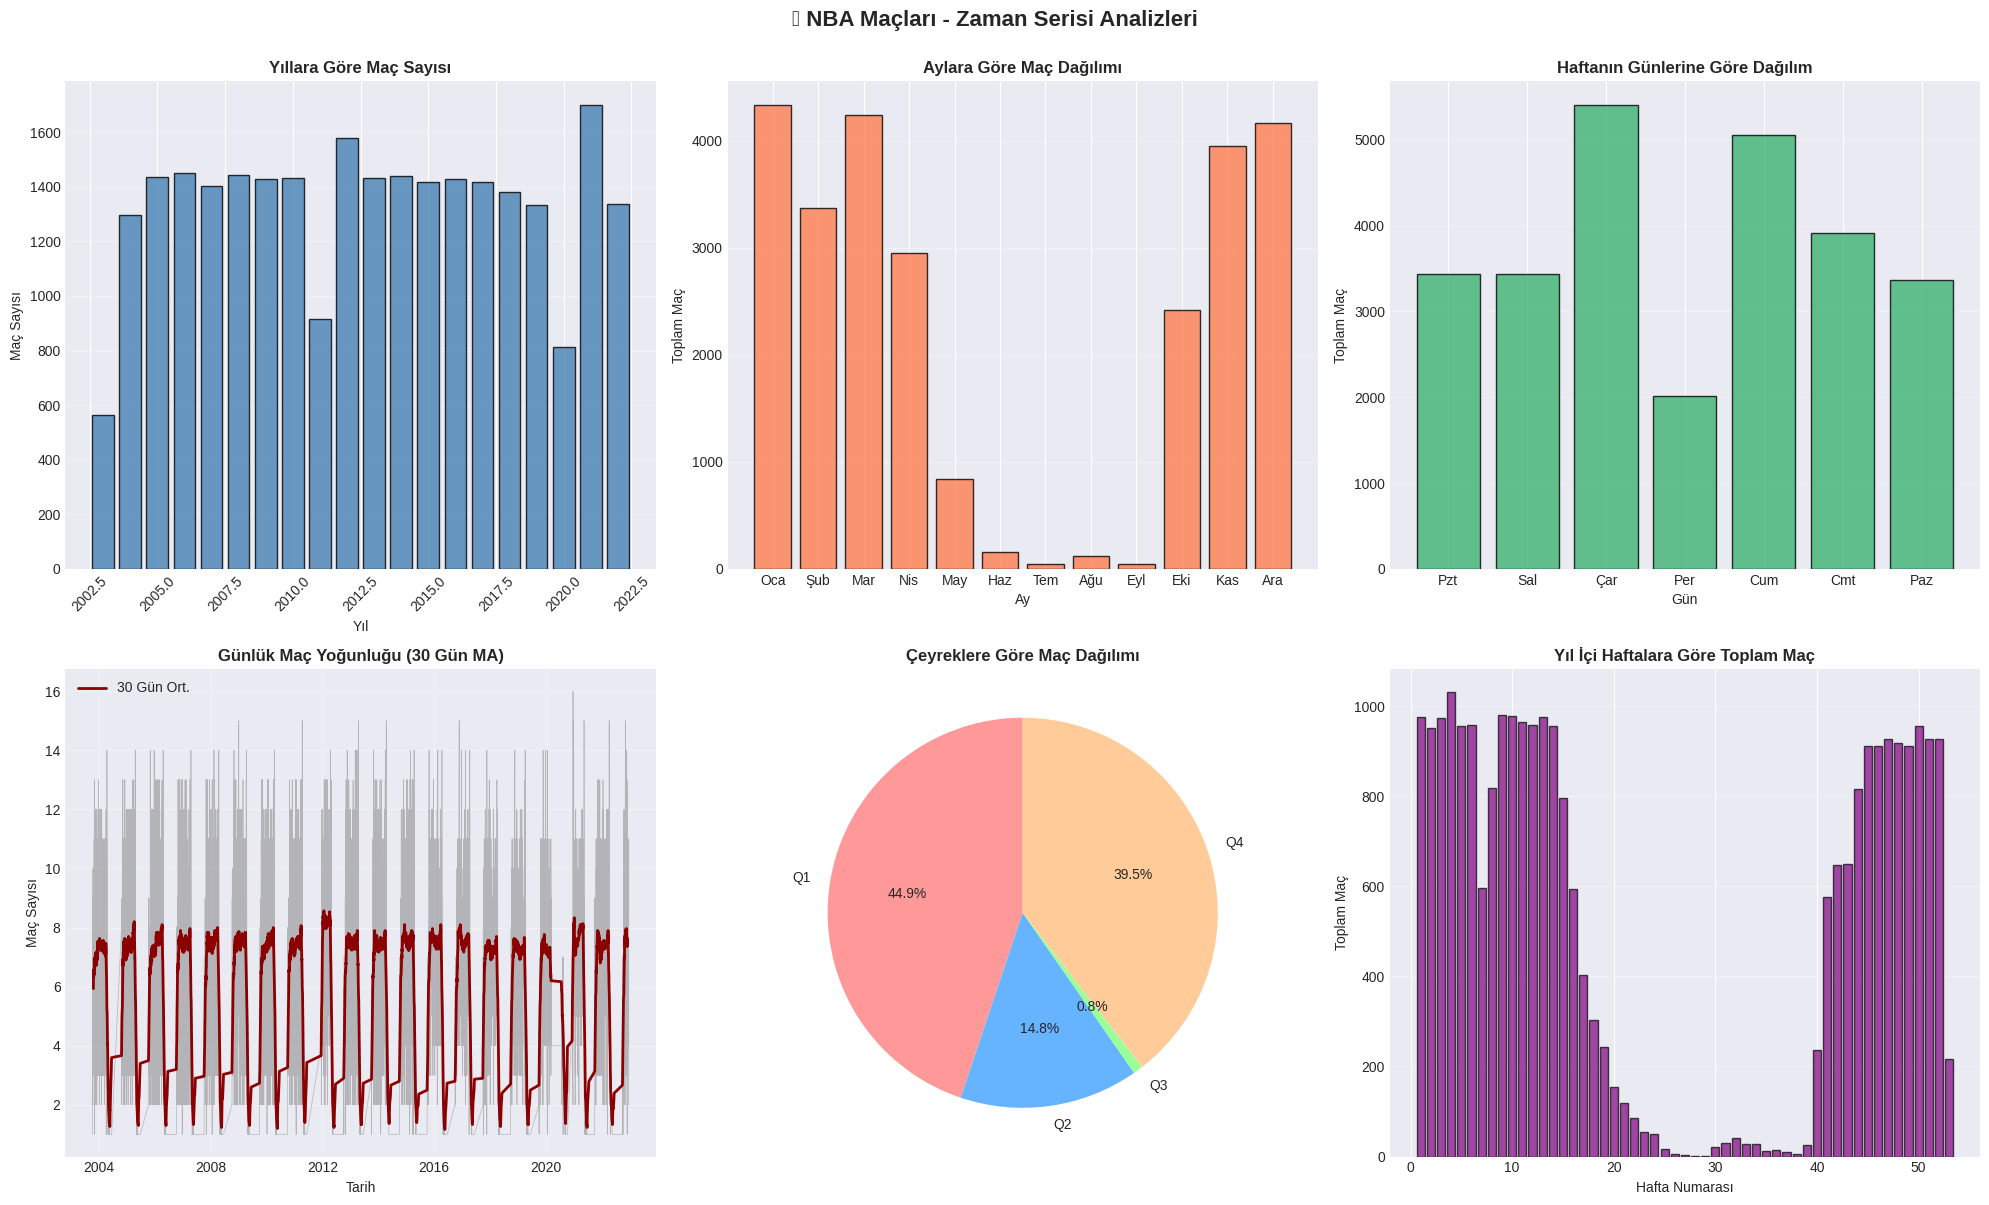

In [16]:
# Kapsamlı zaman serisi grafikleri
if 'Year' in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('🏀 NBA Maçları - Zaman Serisi Analizleri',
                fontsize=16, fontweight='bold', y=1.00)

    # 1. Yıllara göre maç sayısı
    year_counts = df['Year'].value_counts().sort_index()
    axes[0, 0].bar(year_counts.index, year_counts.values,
                  color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_title('Yıllara Göre Maç Sayısı', fontweight='bold')
    axes[0, 0].set_xlabel('Yıl')
    axes[0, 0].set_ylabel('Maç Sayısı')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Aylara göre dağılım
    month_counts = df['Month'].value_counts().sort_index()
    month_names = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
                  'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
    axes[0, 1].bar(month_counts.index, month_counts.values,
                  color='coral', edgecolor='black', alpha=0.8)
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(month_names)
    axes[0, 1].set_title('Aylara Göre Maç Dağılımı', fontweight='bold')
    axes[0, 1].set_xlabel('Ay')
    axes[0, 1].set_ylabel('Toplam Maç')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Haftanın günlerine göre
    day_counts = df['DayOfWeek_Name'].value_counts()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                'Friday', 'Saturday', 'Sunday']
    day_counts = day_counts.reindex(day_order)
    day_names_tr = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
    axes[0, 2].bar(range(7), day_counts.values,
                  color='mediumseagreen', edgecolor='black', alpha=0.8)
    axes[0, 2].set_xticks(range(7))
    axes[0, 2].set_xticklabels(day_names_tr)
    axes[0, 2].set_title('Haftanın Günlerine Göre Dağılım', fontweight='bold')
    axes[0, 2].set_xlabel('Gün')
    axes[0, 2].set_ylabel('Toplam Maç')
    axes[0, 2].grid(axis='y', alpha=0.3)

    # 4. Zamana göre günlük maç yoğunluğu
    games_by_date = df.groupby('GAME_DATE_EST').size().reset_index(name='count')
    axes[1, 0].plot(games_by_date['GAME_DATE_EST'], games_by_date['count'],
                   alpha=0.5, color='gray', linewidth=0.5)
    # 30 günlük hareketli ortalama
    games_by_date['MA30'] = games_by_date['count'].rolling(window=30, center=True).mean()
    axes[1, 0].plot(games_by_date['GAME_DATE_EST'], games_by_date['MA30'],
                   color='darkred', linewidth=2, label='30 Gün Ort.')
    axes[1, 0].set_title('Günlük Maç Yoğunluğu (30 Gün MA)', fontweight='bold')
    axes[1, 0].set_xlabel('Tarih')
    axes[1, 0].set_ylabel('Maç Sayısı')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 5. Çeyrek bazında dağılım
    quarter_counts = df['Quarter'].value_counts().sort_index()
    axes[1, 1].pie(quarter_counts.values, labels=[f'Q{i}' for i in quarter_counts.index],
                  autopct='%1.1f%%', startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
    axes[1, 1].set_title('Çeyreklere Göre Maç Dağılımı', fontweight='bold')

    # 6. Yıl içi haftalara göre yoğunluk
    week_counts = df['Week'].value_counts().sort_index()
    axes[1, 2].bar(week_counts.index, week_counts.values,
                  color='purple', edgecolor='black', alpha=0.7, width=0.8)
    axes[1, 2].set_title('Yıl İçi Haftalara Göre Toplam Maç', fontweight='bold')
    axes[1, 2].set_xlabel('Hafta Numarası')
    axes[1, 2].set_ylabel('Toplam Maç')
    axes[1, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## ⛹️ Skor ve Performans Analizi

In [17]:
# Detaylı skor analizi
print("="*70)
print("⛹️ DETAYLI SKOR İSTATİSTİKLERİ")
print("="*70)

if 'PTS_home' in df.columns:
    home_pts = df['PTS_home']

    print("\n🏠 EV SAHİBİ TAKIMLAR:")
    print(f"  📊 Ortalama: {home_pts.mean():.2f}")
    print(f"  📊 Medyan: {home_pts.median():.2f}")
    print(f"  📊 Mod: {home_pts.mode().values[0] if len(home_pts.mode()) > 0 else 'N/A'}")
    print(f"  📊 Std Sapma: {home_pts.std():.2f}")
    print(f"  📊 Varyans: {home_pts.var():.2f}")
    print(f"  📊 Min: {home_pts.min():.0f}")
    print(f"  📊 Q1 (25%): {home_pts.quantile(0.25):.0f}")
    print(f"  📊 Q3 (75%): {home_pts.quantile(0.75):.0f}")
    print(f"  📊 IQR: {home_pts.quantile(0.75) - home_pts.quantile(0.25):.0f}")
    print(f"  📊 Max: {home_pts.max():.0f}")
    print(f"  📊 Çarpıklık (Skewness): {home_pts.skew():.3f}")
    print(f"  📊 Basıklık (Kurtosis): {home_pts.kurtosis():.3f}")

# Deplasman için aynı şeyi yap
if 'PTS_away' in df.columns:
    away_pts = df['PTS_away']

    print("\n✈️ DEPLASMAN TAKIMLARI:")
    print(f"  📊 Ortalama: {away_pts.mean():.2f}")
    print(f"  📊 Medyan: {away_pts.median():.2f}")
    print(f"  📊 Mod: {away_pts.mode().values[0] if len(away_pts.mode()) > 0 else 'N/A'}")
    print(f"  📊 Std Sapma: {away_pts.std():.2f}")
    print(f"  📊 Varyans: {away_pts.var():.2f}")
    print(f"  📊 Min: {away_pts.min():.0f}")
    print(f"  📊 Q1 (25%): {away_pts.quantile(0.25):.0f}")
    print(f"  📊 Q3 (75%): {away_pts.quantile(0.75):.0f}")
    print(f"  📊 IQR: {away_pts.quantile(0.75) - away_pts.quantile(0.25):.0f}")
    print(f"  📊 Max: {away_pts.max():.0f}")
    print(f"  📊 Çarpıklık (Skewness): {away_pts.skew():.3f}")
    print(f"  📊 Basıklık (Kurtosis): {away_pts.kurtosis():.3f}")

    # İstatistiksel test
    t_stat, p_value = stats.ttest_ind(home_pts, away_pts)
    print(f"\n📊 T-Test Sonuçları:")
    print(f"  t-istatistiği: {t_stat:.4f}")
    print(f"  p-değeri: {p_value:.6f}")
    if p_value < 0.05:
        print(f"  ✅ Ev sahibi ve deplasman skorları ARASINDAistatistiksel olarak anlamlı fark VAR (p < 0.05)")
    else:
        print(f"  ❌ İstatistiksel olarak anlamlı fark YOK (p >= 0.05)")

⛹️ DETAYLI SKOR İSTATİSTİKLERİ

🏠 EV SAHİBİ TAKIMLAR:
  📊 Ortalama: 103.46
  📊 Medyan: 103.00
  📊 Mod: 104.0
  📊 Std Sapma: 13.28
  📊 Varyans: 176.45
  📊 Min: 36
  📊 Q1 (25%): 94
  📊 Q3 (75%): 112
  📊 IQR: 18
  📊 Max: 168
  📊 Çarpıklık (Skewness): 0.173
  📊 Basıklık (Kurtosis): 0.101

✈️ DEPLASMAN TAKIMLARI:
  📊 Ortalama: 100.64
  📊 Medyan: 100.00
  📊 Mod: 98.0
  📊 Std Sapma: 13.44
  📊 Varyans: 180.52
  📊 Min: 33
  📊 Q1 (25%): 91
  📊 Q3 (75%): 110
  📊 IQR: 19
  📊 Max: 168
  📊 Çarpıklık (Skewness): 0.187
  📊 Basıklık (Kurtosis): 0.080

📊 T-Test Sonuçları:
  t-istatistiği: nan
  p-değeri: nan
  ❌ İstatistiksel olarak anlamlı fark YOK (p >= 0.05)


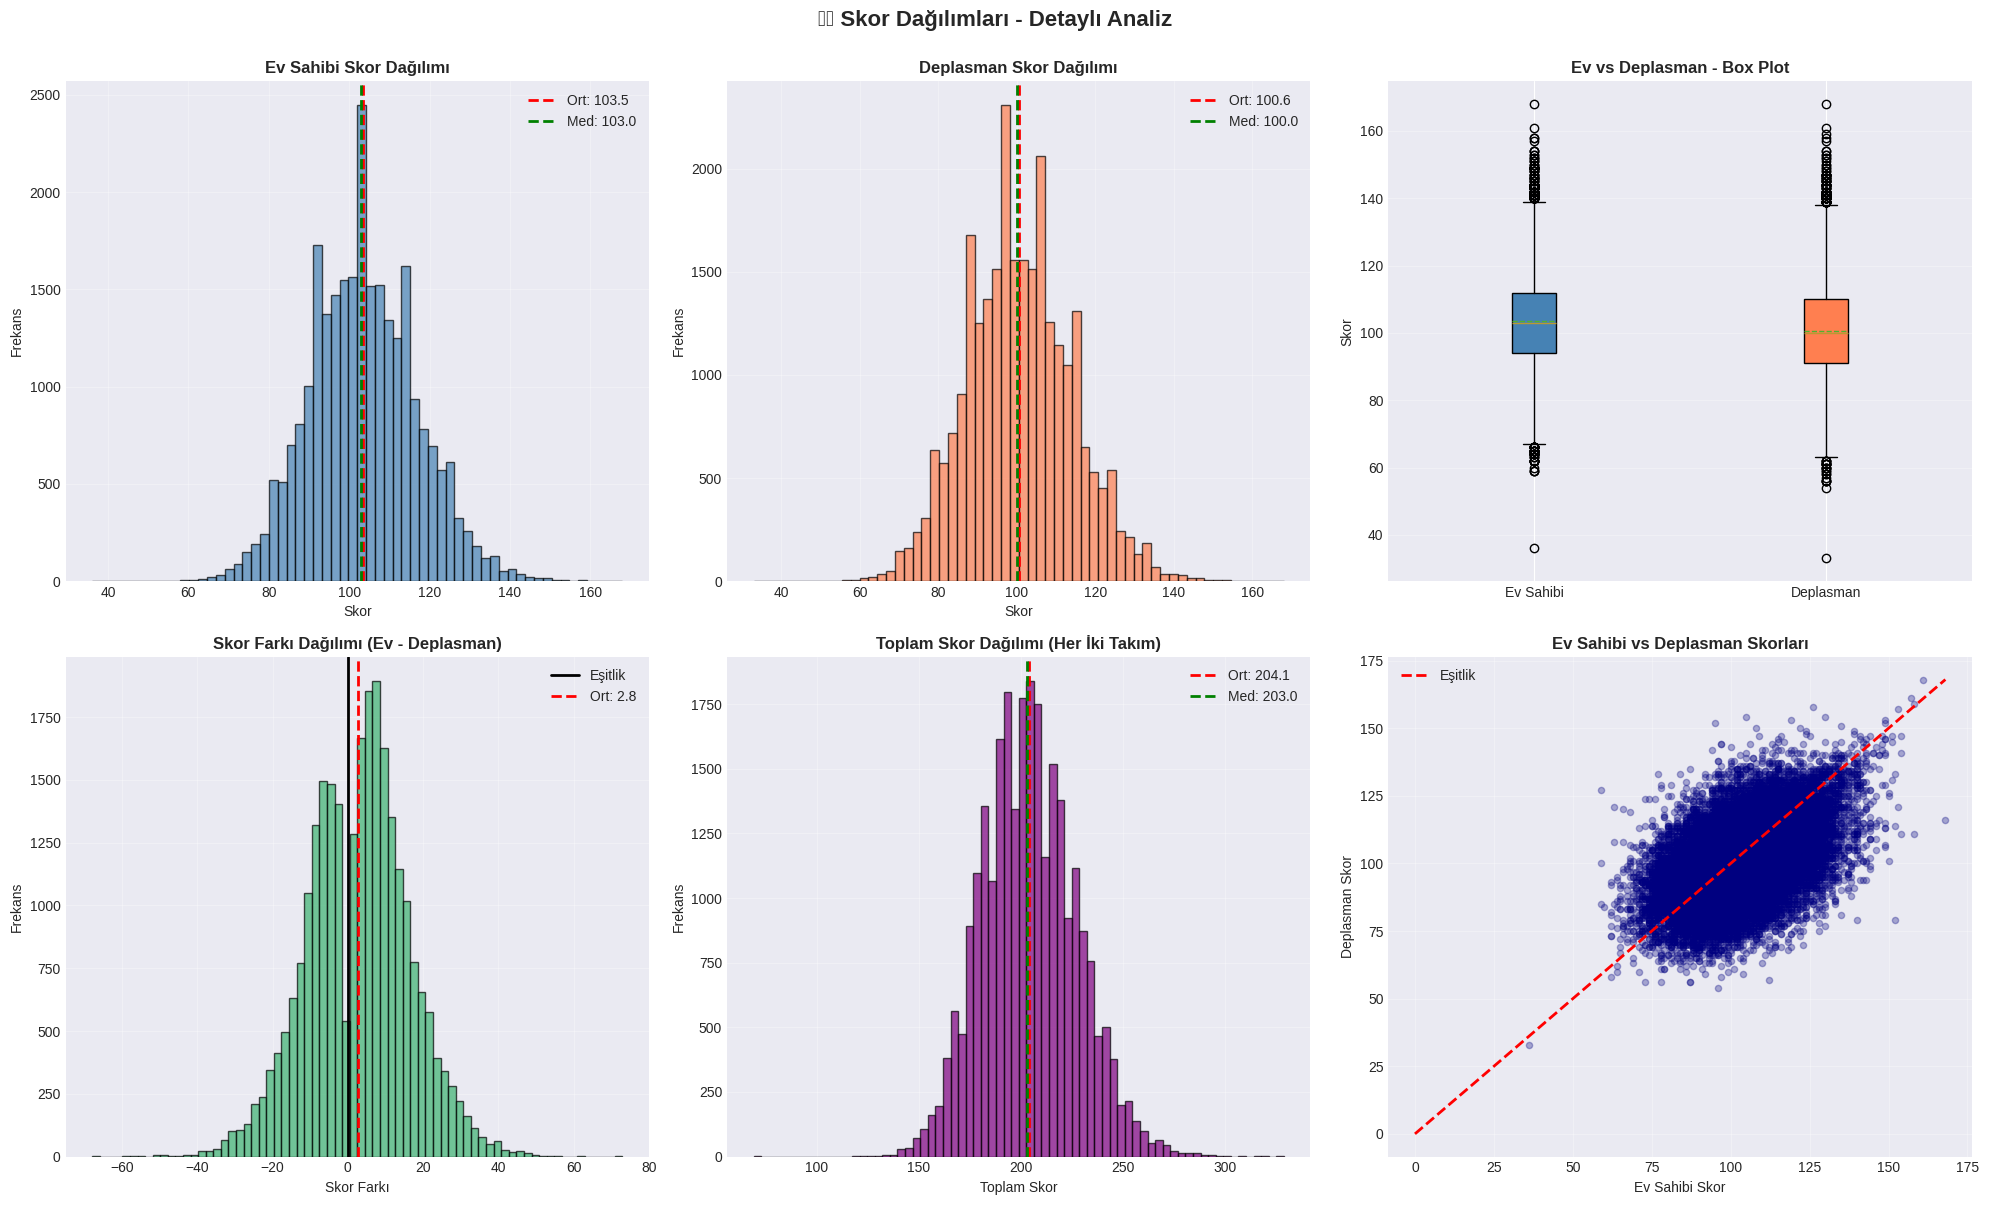

In [18]:
# Skor dağılımları - detaylı görselleştirme
if 'PTS_home' in df.columns and 'PTS_away' in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('⛹️ Skor Dağılımları - Detaylı Analiz',
                fontsize=16, fontweight='bold', y=1.00)

    # 1. Ev sahibi skor histogramı
    axes[0, 0].hist(df['PTS_home'], bins=60, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['PTS_home'].mean(), color='red',
                      linestyle='--', linewidth=2, label=f"Ort: {df['PTS_home'].mean():.1f}")
    axes[0, 0].axvline(df['PTS_home'].median(), color='green',
                      linestyle='--', linewidth=2, label=f"Med: {df['PTS_home'].median():.1f}")
    axes[0, 0].set_title('Ev Sahibi Skor Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Skor')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Deplasman skor histogramı
    axes[0, 1].hist(df['PTS_away'], bins=60, color='coral',
                   edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(df['PTS_away'].mean(), color='red',
                      linestyle='--', linewidth=2, label=f"Ort: {df['PTS_away'].mean():.1f}")
    axes[0, 1].axvline(df['PTS_away'].median(), color='green',
                      linestyle='--', linewidth=2, label=f"Med: {df['PTS_away'].median():.1f}")
    axes[0, 1].set_title('Deplasman Skor Dağılımı', fontweight='bold')
    axes[0, 1].set_xlabel('Skor')
    axes[0, 1].set_ylabel('Frekans')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Box plot karşılaştırması
    data_to_plot = [df['PTS_home'].dropna(), df['PTS_away'].dropna()]
    bp = axes[0, 2].boxplot(data_to_plot, labels=['Ev Sahibi', 'Deplasman'],
                           patch_artist=True, showmeans=True, meanline=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[0, 2].set_title('Ev vs Deplasman - Box Plot', fontweight='bold')
    axes[0, 2].set_ylabel('Skor')
    axes[0, 2].grid(axis='y', alpha=0.3)

    # 4. Skor farkı dağılımı
    df['Score_Diff'] = df['PTS_home'] - df['PTS_away']
    axes[1, 0].hist(df['Score_Diff'], bins=70, color='mediumseagreen',
                   edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=2, label='Eşitlik')
    axes[1, 0].axvline(df['Score_Diff'].mean(), color='red',
                      linestyle='--', linewidth=2, label=f"Ort: {df['Score_Diff'].mean():.1f}")
    axes[1, 0].set_title('Skor Farkı Dağılımı (Ev - Deplasman)', fontweight='bold')
    axes[1, 0].set_xlabel('Skor Farkı')
    axes[1, 0].set_ylabel('Frekans')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 5. Toplam skor dağılımı
    df['Total_Points'] = df['PTS_home'] + df['PTS_away']
    axes[1, 1].hist(df['Total_Points'], bins=70, color='purple',
                   edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(df['Total_Points'].mean(), color='red',
                      linestyle='--', linewidth=2, label=f"Ort: {df['Total_Points'].mean():.1f}")
    axes[1, 1].axvline(df['Total_Points'].median(), color='green',
                      linestyle='--', linewidth=2, label=f"Med: {df['Total_Points'].median():.1f}")
    axes[1, 1].set_title('Toplam Skor Dağılımı (Her İki Takım)', fontweight='bold')
    axes[1, 1].set_xlabel('Toplam Skor')
    axes[1, 1].set_ylabel('Frekans')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    # 6. Scatter plot - Ev vs Deplasman
    axes[1, 2].scatter(df['PTS_home'], df['PTS_away'],
                      alpha=0.3, s=20, color='navy')
    # Eşitlik çizgisi
    max_pts = max(df['PTS_home'].max(), df['PTS_away'].max())
    axes[1, 2].plot([0, max_pts], [0, max_pts], 'r--', linewidth=2, label='Eşitlik')
    axes[1, 2].set_title('Ev Sahibi vs Deplasman Skorları', fontweight='bold')
    axes[1, 2].set_xlabel('Ev Sahibi Skor')
    axes[1, 2].set_ylabel('Deplasman Skor')
    axes[1, 2].legend()
    axes[1, 2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🏠 Ev Sahibi Avantajı Detaylı Analizi

In [19]:
# Ev sahibi avantajı hesaplama
if 'HOME_TEAM_WINS' in df.columns:
    home_wins = df['HOME_TEAM_WINS'].sum()
    total_games = len(df)
    away_wins = total_games - home_wins
    home_win_pct = (home_wins / total_games) * 100
    away_win_pct = (away_wins / total_games) * 100

    print("="*70)
    print("🏠 EV SAHİBİ AVANTAJI - DETAYLI ANALİZ")
    print("="*70)

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Toplam Maç: {total_games:,}")
    print(f"  Ev Sahibi Galibiyet: {home_wins:,}")
    print(f"  Deplasman Galibiyet: {away_wins:,}")
    print(f"  Ev Sahibi Kazanma Oranı: {home_win_pct:.2f}%")
    print(f"  Deplasman Kazanma Oranı: {away_win_pct:.2f}%")
    print(f"  Ev Avantajı: {home_win_pct - 50:.2f} puan")

    # Chi-square test
    expected = total_games / 2
    chi_stat = ((home_wins - expected)**2 / expected +
                (away_wins - expected)**2 / expected)

    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(chi_stat, df=1)

    print(f"\n📊 İstatistiksel Test (Chi-Square):")
    print(f"  Chi-square istatistiği: {chi_stat:.2f}")
    print(f"  p-değeri: {p_value:.10f}")
    print(f"  Kritik değer (α=0.05): 3.84")

    if chi_stat > 3.84:
        print(f"  ✅ Ev sahibi avantajı İSTATİSTİKSEL OLARAK ANLAMLI (p < 0.05)")
    else:
        print(f"  ❌ Ev sahibi avantajı istatistiksel olarak anlamlı değil")

    # Yıllara göre ev sahibi avantajı
    if 'Year' in df.columns:
        yearly_home_adv = df.groupby('Year')['HOME_TEAM_WINS'].agg(['sum', 'count'])
        yearly_home_adv['Win_Pct'] = (yearly_home_adv['sum'] / yearly_home_adv['count']) * 100

        print(f"\n📊 Yıllara Göre Ev Sahibi Kazanma Oranı:")
        for year, row in yearly_home_adv.iterrows():
            print(f"  {year}: {row['Win_Pct']:>5.2f}% ({int(row['sum']):>4}/{int(row['count']):>4})")

🏠 EV SAHİBİ AVANTAJI - DETAYLI ANALİZ

📊 Genel İstatistikler:
  Toplam Maç: 26,651
  Ev Sahibi Galibiyet: 15,645
  Deplasman Galibiyet: 11,006
  Ev Sahibi Kazanma Oranı: 58.70%
  Deplasman Kazanma Oranı: 41.30%
  Ev Avantajı: 8.70 puan

📊 İstatistiksel Test (Chi-Square):
  Chi-square istatistiği: 807.49
  p-değeri: 0.0000000000
  Kritik değer (α=0.05): 3.84
  ✅ Ev sahibi avantajı İSTATİSTİKSEL OLARAK ANLAMLI (p < 0.05)

📊 Yıllara Göre Ev Sahibi Kazanma Oranı:
  2003: 51.77% ( 292/ 564)
  2004: 61.31% ( 794/1295)
  2005: 59.02% ( 847/1435)
  2006: 61.89% ( 898/1451)
  2007: 58.48% ( 821/1404)
  2008: 59.99% ( 865/1442)
  2009: 62.75% ( 896/1428)
  2010: 59.92% ( 858/1432)
  2011: 61.09% ( 559/ 915)
  2012: 60.25% ( 952/1580)
  2013: 58.73% ( 841/1432)
  2014: 56.90% ( 820/1441)
  2015: 59.62% ( 846/1419)
  2016: 58.36% ( 834/1429)
  2017: 58.15% ( 824/1417)
  2018: 59.62% ( 824/1382)
  2019: 56.53% ( 753/1332)
  2020: 52.21% ( 425/ 814)
  2021: 55.14% ( 938/1701)
  2022: 56.65% ( 758/13

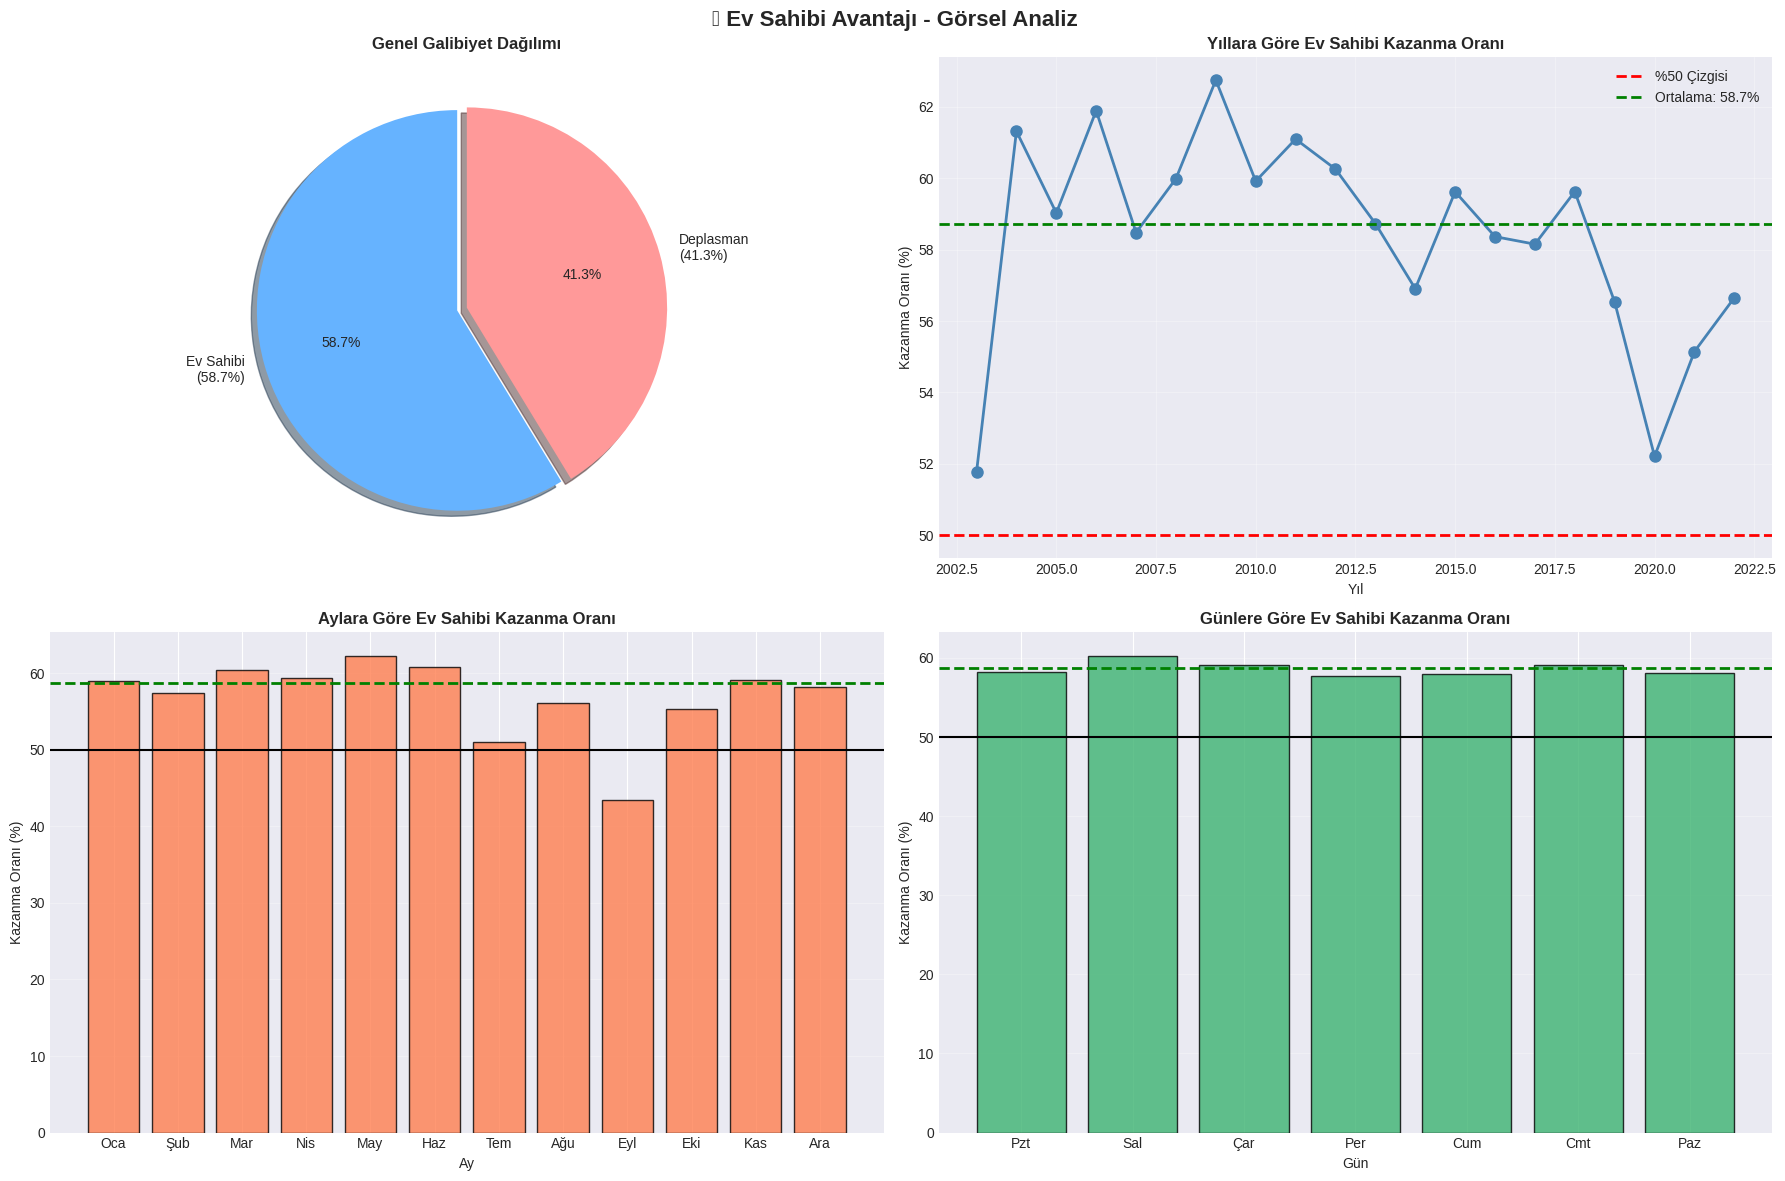

In [20]:
# Ev sahibi avantajı görselleştirme
if 'HOME_TEAM_WINS' in df.columns and 'Year' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('🏠 Ev Sahibi Avantajı - Görsel Analiz',
                fontsize=16, fontweight='bold')

    # 1. Genel dağılım - Pie chart
    sizes = [home_wins, away_wins]
    labels = [f'Ev Sahibi\n({home_win_pct:.1f}%)',
             f'Deplasman\n({away_win_pct:.1f}%)']
    colors = ['#66b3ff', '#ff9999']
    explode = (0.05, 0)
    axes[0, 0].pie(sizes, explode=explode, labels=labels, colors=colors,
                  autopct='%1.1f%%', shadow=True, startangle=90)
    axes[0, 0].set_title('Genel Galibiyet Dağılımı', fontweight='bold')

    # 2. Yıllara göre trend
    yearly_home_adv = df.groupby('Year')['HOME_TEAM_WINS'].agg(['sum', 'count'])
    yearly_home_adv['Win_Pct'] = (yearly_home_adv['sum'] / yearly_home_adv['count']) * 100
    axes[0, 1].plot(yearly_home_adv.index, yearly_home_adv['Win_Pct'],
                   marker='o', linewidth=2, markersize=8, color='steelblue')
    axes[0, 1].axhline(50, color='red', linestyle='--', linewidth=2, label='%50 Çizgisi')
    axes[0, 1].axhline(home_win_pct, color='green', linestyle='--',
                      linewidth=2, label=f'Ortalama: {home_win_pct:.1f}%')
    axes[0, 1].set_title('Yıllara Göre Ev Sahibi Kazanma Oranı', fontweight='bold')
    axes[0, 1].set_xlabel('Yıl')
    axes[0, 1].set_ylabel('Kazanma Oranı (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Aylara göre ev sahibi avantajı
    monthly_home_adv = df.groupby('Month')['HOME_TEAM_WINS'].agg(['sum', 'count'])
    monthly_home_adv['Win_Pct'] = (monthly_home_adv['sum'] / monthly_home_adv['count']) * 100
    month_names = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
                  'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
    axes[1, 0].bar(monthly_home_adv.index, monthly_home_adv['Win_Pct'],
                  color='coral', edgecolor='black', alpha=0.8)
    axes[1, 0].axhline(50, color='black', linestyle='-', linewidth=1.5)
    axes[1, 0].axhline(home_win_pct, color='green', linestyle='--', linewidth=2)
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].set_xticklabels(month_names)
    axes[1, 0].set_title('Aylara Göre Ev Sahibi Kazanma Oranı', fontweight='bold')
    axes[1, 0].set_xlabel('Ay')
    axes[1, 0].set_ylabel('Kazanma Oranı (%)')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Haftanın günlerine göre
    daily_home_adv = df.groupby('DayOfWeek_Name')['HOME_TEAM_WINS'].agg(['sum', 'count'])
    daily_home_adv['Win_Pct'] = (daily_home_adv['sum'] / daily_home_adv['count']) * 100
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                'Friday', 'Saturday', 'Sunday']
    daily_home_adv = daily_home_adv.reindex(day_order)
    day_names_tr = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
    axes[1, 1].bar(range(7), daily_home_adv['Win_Pct'],
                  color='mediumseagreen', edgecolor='black', alpha=0.8)
    axes[1, 1].axhline(50, color='black', linestyle='-', linewidth=1.5)
    axes[1, 1].axhline(home_win_pct, color='green', linestyle='--', linewidth=2)
    axes[1, 1].set_xticks(range(7))
    axes[1, 1].set_xticklabels(day_names_tr)
    axes[1, 1].set_title('Günlere Göre Ev Sahibi Kazanma Oranı', fontweight='bold')
    axes[1, 1].set_xlabel('Gün')
    axes[1, 1].set_ylabel('Kazanma Oranı (%)')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🎯 Şut Verimliliği ve Yüzdeler Analizi

In [21]:
# Şut yüzdesi sütunlarını tespit et
fg_cols = [col for col in df.columns if 'FG_PCT' in col or 'FT_PCT' in col or 'FG3_PCT' in col]

if fg_cols:
    print("="*70)
    print("🎯 ŞUT VERİMLİLİĞİ - DETAYLI ANALİZ")
    print("="*70)

    for col in fg_cols:
        data = df[col].dropna()

        print(f"\n📊 {col}:")
        print(f"  Ortalama: {data.mean():.4f} ({data.mean()*100:.2f}%)")
        print(f"  Medyan: {data.median():.4f} ({data.median()*100:.2f}%)")
        print(f"  Std Sapma: {data.std():.4f}")
        print(f"  Min: {data.min():.4f} ({data.min()*100:.2f}%)")
        print(f"  Max: {data.max():.4f} ({data.max()*100:.2f}%)")
        print(f"  Q1: {data.quantile(0.25):.4f}")
        print(f"  Q3: {data.quantile(0.75):.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")

🎯 ŞUT VERİMLİLİĞİ - DETAYLI ANALİZ

📊 FG_PCT_home:
  Ortalama: 0.4607 (46.07%)
  Medyan: 0.4600 (46.00%)
  Std Sapma: 0.0567
  Min: 0.2500 (25.00%)
  Max: 0.6840 (68.40%)
  Q1: 0.4220
  Q3: 0.5000
  IQR: 0.0780

📊 FT_PCT_home:
  Ortalama: 0.7604 (76.04%)
  Medyan: 0.7650 (76.50%)
  Std Sapma: 0.1007
  Min: 0.1430 (14.30%)
  Max: 1.0000 (100.00%)
  Q1: 0.6970
  Q3: 0.8330
  IQR: 0.1360

📊 FG3_PCT_home:
  Ortalama: 0.3560 (35.60%)
  Medyan: 0.3570 (35.70%)
  Std Sapma: 0.1112
  Min: 0.0000 (0.00%)
  Max: 1.0000 (100.00%)
  Q1: 0.2860
  Q3: 0.4290
  IQR: 0.1430

📊 FG_PCT_away:
  Ortalama: 0.4497 (44.97%)
  Medyan: 0.4490 (44.90%)
  Std Sapma: 0.0556
  Min: 0.2440 (24.40%)
  Max: 0.6870 (68.70%)
  Q1: 0.4120
  Q3: 0.4870
  IQR: 0.0750

📊 FT_PCT_away:
  Ortalama: 0.7588 (75.88%)
  Medyan: 0.7650 (76.50%)
  Std Sapma: 0.1034
  Min: 0.1430 (14.30%)
  Max: 1.0000 (100.00%)
  Q1: 0.6920
  Q3: 0.8330
  IQR: 0.1410

📊 FG3_PCT_away:
  Ortalama: 0.3495 (34.95%)
  Medyan: 0.3500 (35.00%)
  Std Sapma

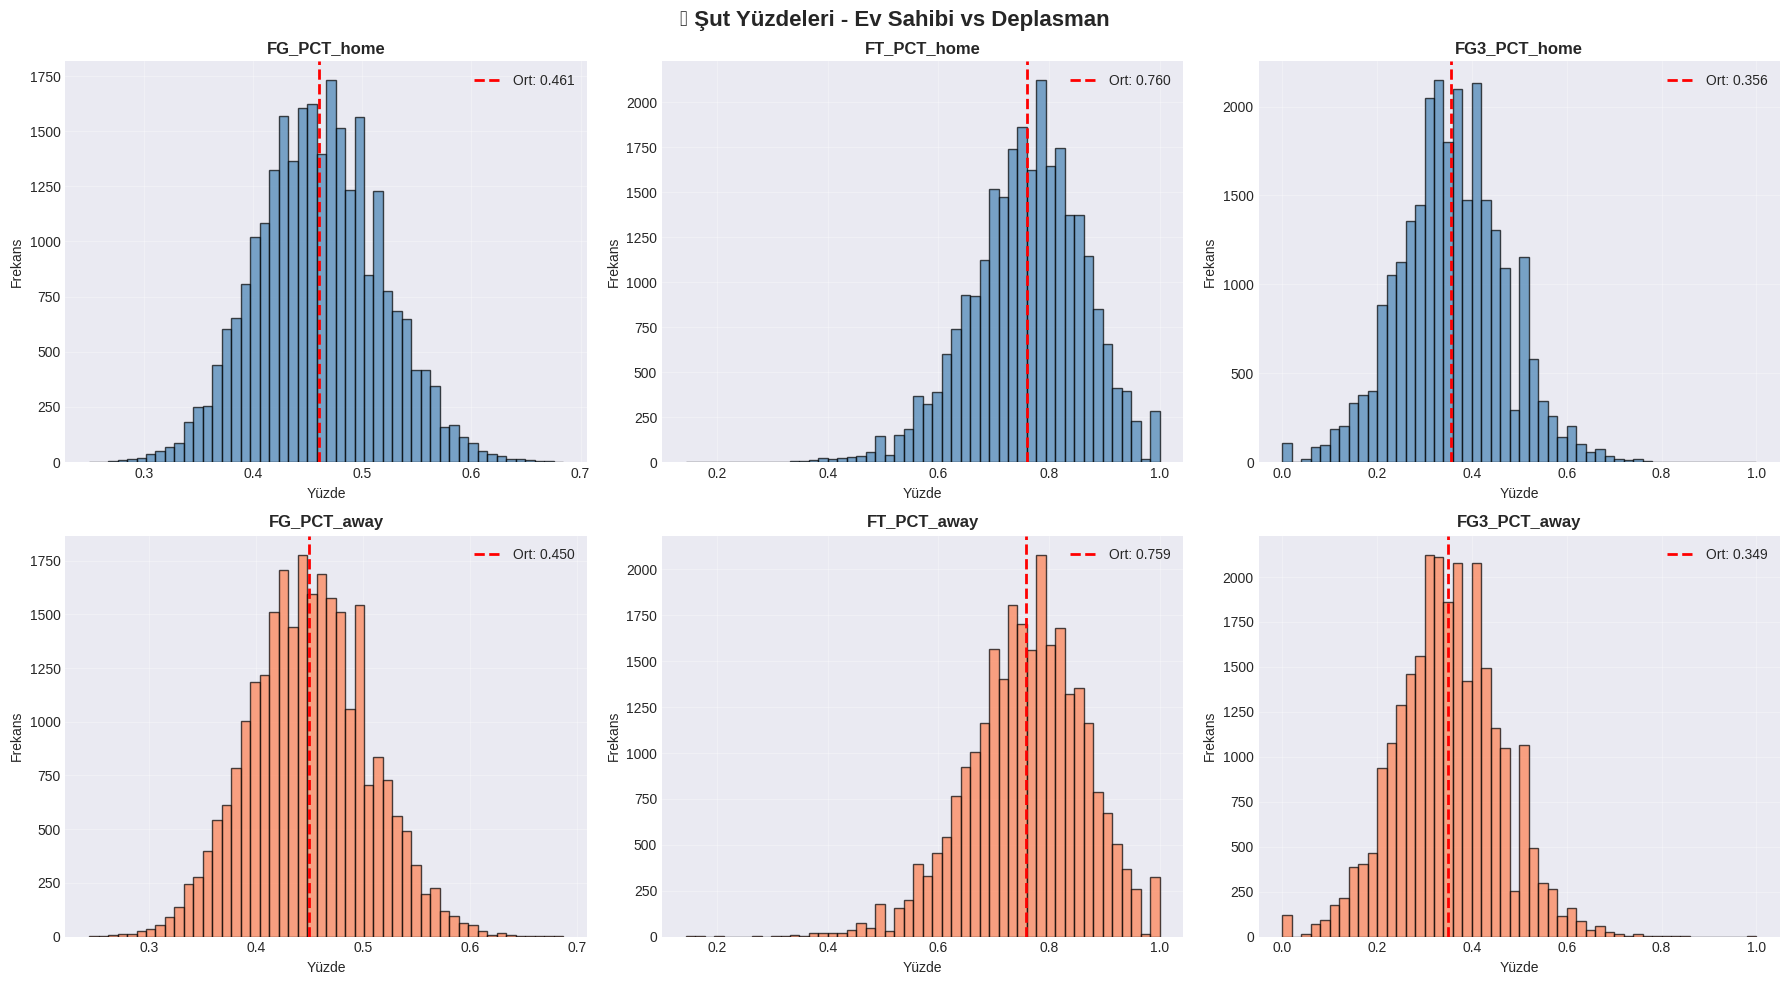

In [22]:
# Şut yüzdesi görselleştirmeleri
home_fg_cols = [col for col in fg_cols if 'home' in col.lower()]
away_fg_cols = [col for col in fg_cols if 'away' in col.lower()]

if home_fg_cols and away_fg_cols:
    n_metrics = min(len(home_fg_cols), 3)  # Maksimum 3 metrik

    fig, axes = plt.subplots(2, n_metrics, figsize=(6*n_metrics, 10))
    fig.suptitle('🎯 Şut Yüzdeleri - Ev Sahibi vs Deplasman',
                fontsize=16, fontweight='bold')

    if n_metrics == 1:
        axes = axes.reshape(-1, 1)

    for idx in range(n_metrics):
        home_col = home_fg_cols[idx]
        away_col = away_fg_cols[idx] if idx < len(away_fg_cols) else None

        # Ev sahibi
        home_data = df[home_col].dropna()
        axes[0, idx].hist(home_data, bins=50, color='steelblue',
                         edgecolor='black', alpha=0.7)
        axes[0, idx].axvline(home_data.mean(), color='red',
                            linestyle='--', linewidth=2,
                            label=f"Ort: {home_data.mean():.3f}")
        axes[0, idx].set_title(f'{home_col}', fontweight='bold')
        axes[0, idx].set_xlabel('Yüzde')
        axes[0, idx].set_ylabel('Frekans')
        axes[0, idx].legend()
        axes[0, idx].grid(alpha=0.3)

        # Deplasman
        if away_col:
            away_data = df[away_col].dropna()
            axes[1, idx].hist(away_data, bins=50, color='coral',
                             edgecolor='black', alpha=0.7)
            axes[1, idx].axvline(away_data.mean(), color='red',
                                linestyle='--', linewidth=2,
                                label=f"Ort: {away_data.mean():.3f}")
            axes[1, idx].set_title(f'{away_col}', fontweight='bold')
            axes[1, idx].set_xlabel('Yüzde')
            axes[1, idx].set_ylabel('Frekans')
            axes[1, idx].legend()
            axes[1, idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 📊 Korelasyon Analizi

In [23]:
# Sayısal sütunları seç (ID'ler hariç)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols
               if not col.endswith('_ID') and col not in ['GAME_ID', 'Year', 'Month', 'Day']]

print("="*70)
print("📊 KORELASYON ANALİZİ")
print("="*70)
print(f"\nAnaliz edilen sütun sayısı: {len(numeric_cols)}")

# Korelasyon matrisi
corr_matrix = df[numeric_cols].corr()

# En yüksek korelasyonları bul
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append((
            corr_matrix.columns[i],
            corr_matrix.columns[j],
            corr_matrix.iloc[i, j]
        ))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\n🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 20):")
print("="*70)
for idx, (col1, col2, corr) in enumerate(corr_pairs_sorted[:20], 1):
    print(f"{idx:2d}. {col1:25} <-> {col2:25} : {corr:7.4f}")

print("\n🔻 EN YÜKSEK NEGATİF KORELASYONLAR (Top 20):")
print("="*70)
neg_corr = sorted(corr_pairs, key=lambda x: x[2])[:20]
for idx, (col1, col2, corr) in enumerate(neg_corr, 1):
    print(f"{idx:2d}. {col1:25} <-> {col2:25} : {corr:7.4f}")

📊 KORELASYON ANALİZİ

Analiz edilen sütun sayısı: 21

🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 20):
 1. Quarter                   <-> Week                      :  0.9531
 2. PTS_away                  <-> Total_Points              :  0.8643
 3. PTS_home                  <-> Total_Points              :  0.8609
 4. HOME_TEAM_WINS            <-> Score_Diff                :  0.8008
 5. PTS_away                  <-> FG_PCT_away               :  0.6691
 6. PTS_home                  <-> FG_PCT_home               :  0.6622
 7. PTS_home                  <-> AST_home                  :  0.6054
 8. PTS_away                  <-> AST_away                  :  0.5958
 9. FG_PCT_home               <-> AST_home                  :  0.5508
10. FG_PCT_away               <-> Score_Diff                : -0.5352
11. FG_PCT_home               <-> Score_Diff                :  0.5331
12. FG_PCT_away               <-> AST_away                  :  0.5255
13. PTS_away                  <-> Score_Diff                : 

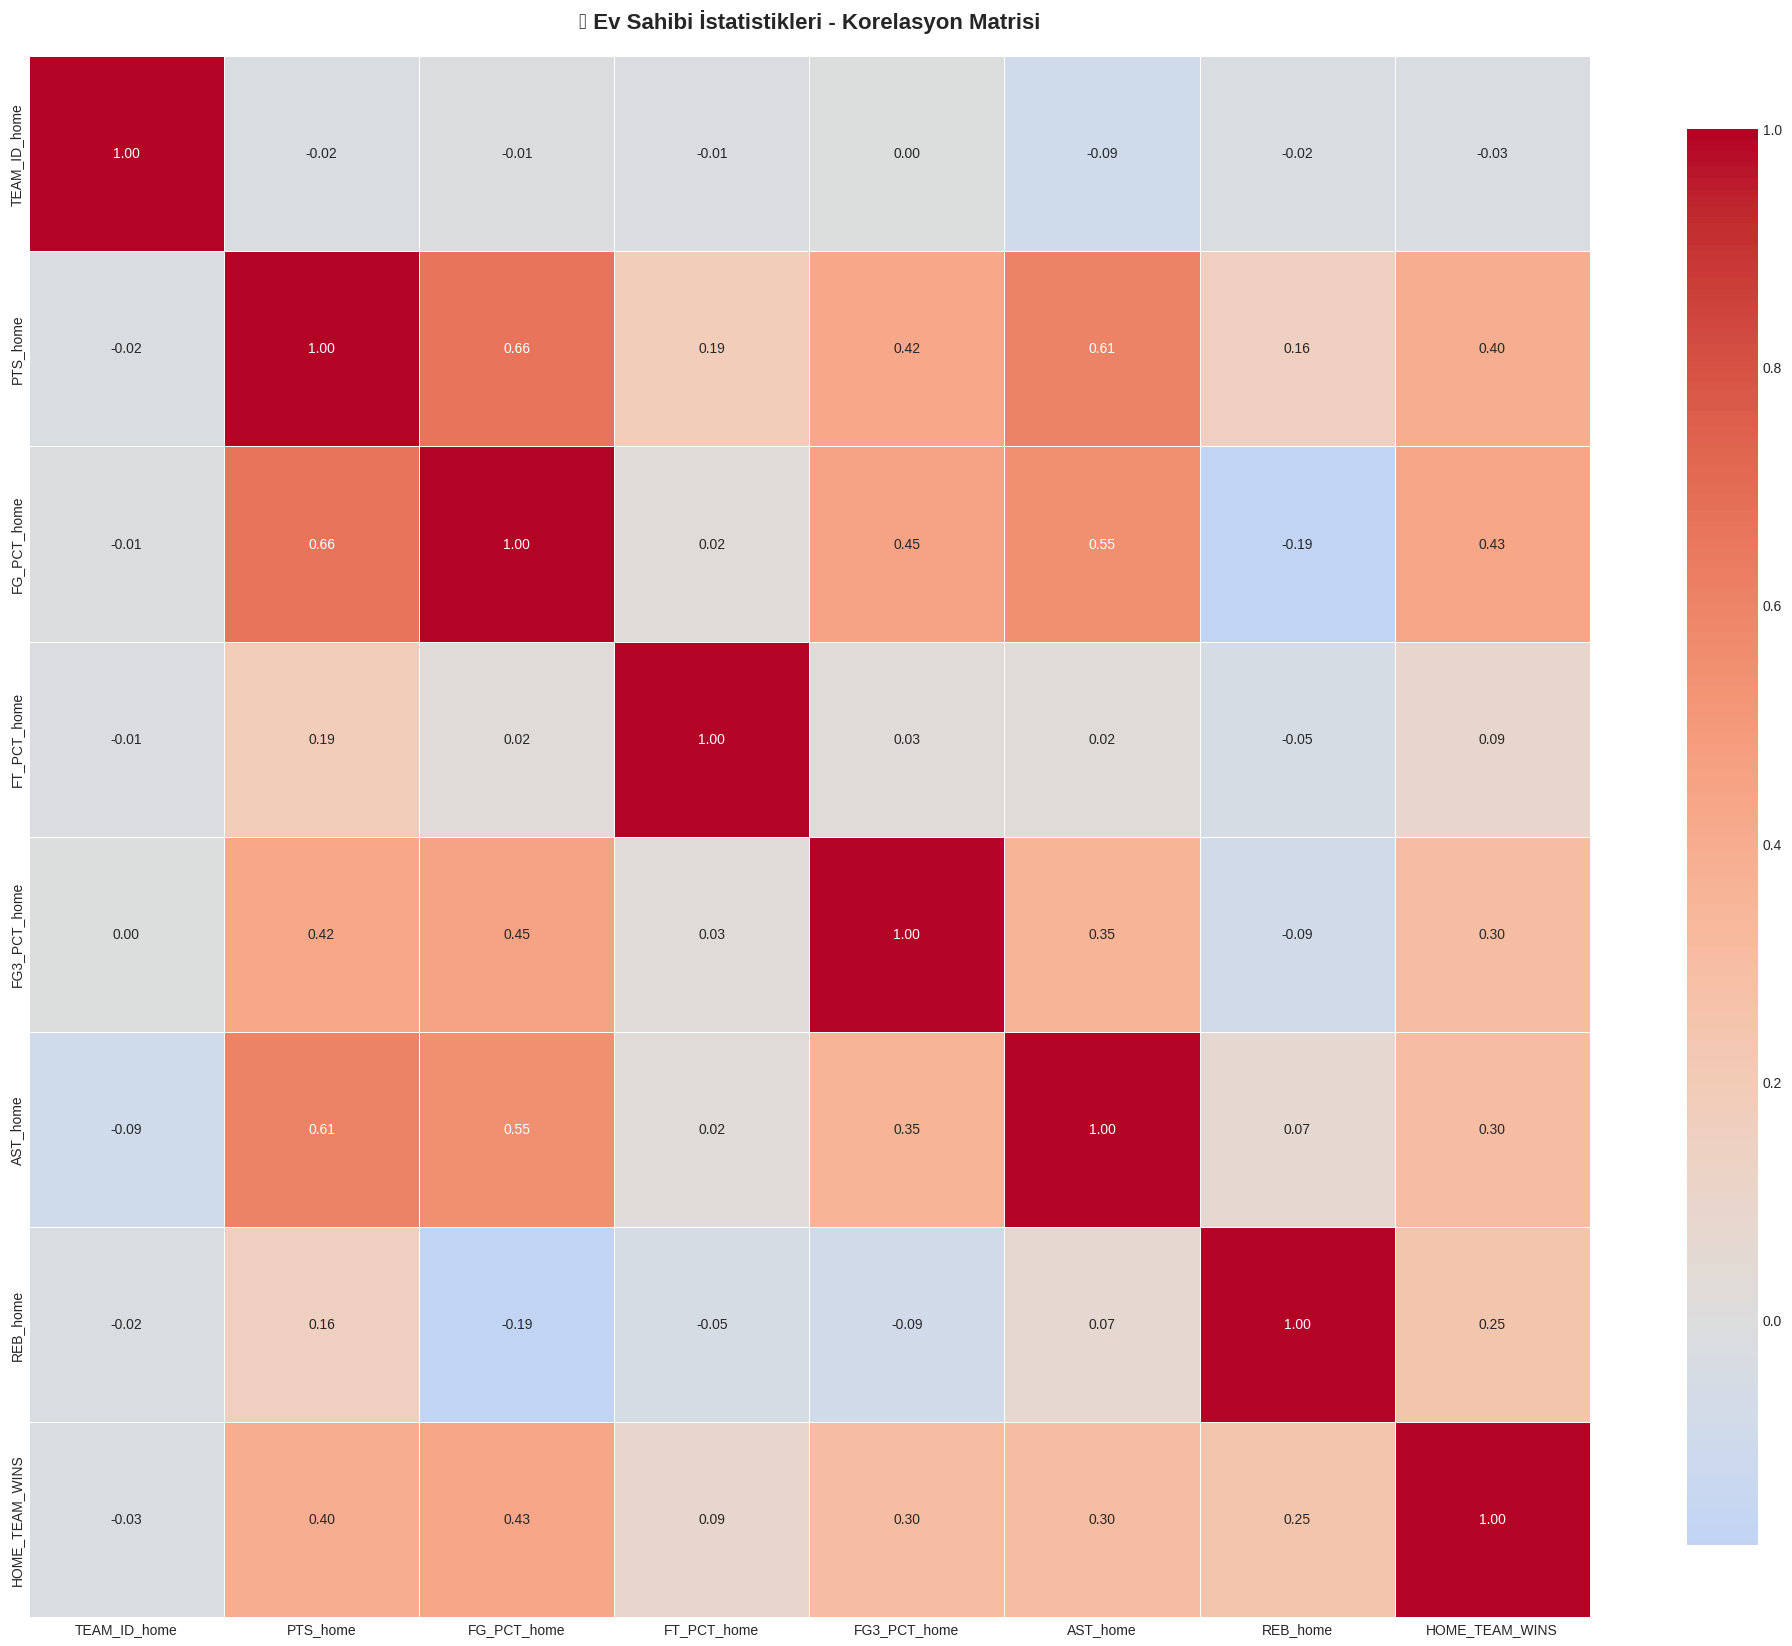

In [24]:
# Korelasyon heatmap (ev sahibi istatistikleri)
home_stats = [col for col in numeric_cols if 'home' in col.lower()]

if len(home_stats) > 2:
    # Çok fazla varsa ilk 25'ini al
    home_stats_subset = home_stats[:25]
    corr_home = df[home_stats_subset].corr()

    plt.figure(figsize=(20, 18))
    sns.heatmap(corr_home, annot=True, fmt=".2f", cmap='coolwarm',
               center=0, linewidths=0.5, cbar_kws={"shrink": 0.8},
               square=True)
    plt.title('🏠 Ev Sahibi İstatistikleri - Korelasyon Matrisi',
             fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## 🏆 İleri Düzey Analizler

In [25]:
# Yüksek skorlu maçlar
if 'Total_Points' in df.columns:
    print("="*70)
    print("🔥 EN YÜKSEK SKORLU MAÇLAR (Top 20)")
    print("="*70)

    cols_to_show = ['GAME_DATE_EST', 'PTS_home', 'PTS_away', 'Total_Points']
    if 'SEASON' in df.columns:
        cols_to_show.insert(1, 'SEASON')

    high_scoring = df.nlargest(20, 'Total_Points')[cols_to_show]
    print(high_scoring.to_string(index=False))

    print("\n" + "="*70)
    print("❄️ EN DÜŞÜK SKORLU MAÇLAR (Top 20)")
    print("="*70)

    low_scoring = df.nsmallest(20, 'Total_Points')[cols_to_show]
    print(low_scoring.to_string(index=False))

🔥 EN YÜKSEK SKORLU MAÇLAR (Top 20)
GAME_DATE_EST  SEASON  PTS_home  PTS_away  Total_Points
   2019-03-01    2018   161.000   168.000       329.000
   2006-12-07    2006   157.000   161.000       318.000
   2019-10-30    2019   158.000   159.000       317.000
   2022-02-25    2021   153.000   157.000       310.000
   2020-07-31    2019   149.000   153.000       302.000
   2006-01-22    2005   149.000   152.000       301.000
   2019-01-10    2018   154.000   147.000       301.000
   2008-04-06    2007   151.000   147.000       298.000
   2006-12-27    2006   151.000   145.000       296.000
   2021-05-03    2020   154.000   141.000       295.000
   2021-01-31    2020   149.000   146.000       295.000
   2019-02-22    2018   148.000   147.000       295.000
   2018-12-22    2018   149.000   146.000       295.000
   2019-03-25    2018   148.000   144.000       292.000
   2015-12-18    2015   144.000   147.000       291.000
   2018-03-19    2017   149.000   141.000       290.000
   2017-12-31

In [26]:
# Çekişmeli maçlar analizi
if 'Score_Diff' in df.columns:
    # Farklı eşik değerleri
    thresholds = [3, 5, 10, 20]

    print("="*70)
    print("⚔️ ÇEKİŞMELİ / FARKLI MAÇ ANALİZİ")
    print("="*70)

    for threshold in thresholds:
        close_games = df[abs(df['Score_Diff']) <= threshold]
        close_pct = (len(close_games) / len(df)) * 100
        print(f"\n📊 Skor Farkı ≤ {threshold}:")
        print(f"  Maç Sayısı: {len(close_games):,}")
        print(f"  Yüzde: {close_pct:.2f}%")

    # Çok farklı maçlar
    blowouts = df[abs(df['Score_Diff']) > 20]
    blowout_pct = (len(blowouts) / len(df)) * 100
    print(f"\n📊 Farklı Maçlar (|fark| > 20):")
    print(f"  Maç Sayısı: {len(blowouts):,}")
    print(f"  Yüzde: {blowout_pct:.2f}%")

⚔️ ÇEKİŞMELİ / FARKLI MAÇ ANALİZİ

📊 Skor Farkı ≤ 3:
  Maç Sayısı: 4,074
  Yüzde: 15.29%

📊 Skor Farkı ≤ 5:
  Maç Sayısı: 7,336
  Yüzde: 27.53%

📊 Skor Farkı ≤ 10:
  Maç Sayısı: 15,115
  Yüzde: 56.71%

📊 Skor Farkı ≤ 20:
  Maç Sayısı: 23,057
  Yüzde: 86.51%

📊 Farklı Maçlar (|fark| > 20):
  Maç Sayısı: 3,495
  Yüzde: 13.11%



📈 SEZONLARA GÖRE İSTATİSTİKLER
        Game_Count  PTS_home  PTS_away  Avg_Total
SEASON                                           
2003          1385    94.907    91.093    186.000
2004          1362    98.605    95.382    193.987
2005          1432    98.406    95.172    193.579
2006          1419    99.849    96.944    196.794
2007          1411   101.274    97.549    198.823
2008          1425   100.923    97.904    198.827
2009          1424   101.654    98.746    200.400
2010          1422   100.757    97.385    198.141
2011          1104    97.392    94.429    191.822
2012          1420    99.382    96.114    195.496
2013          1427   101.735    99.261    200.996
2014          1418   101.095    98.815    199.910
2015          1416   103.713   100.765    204.477
2016          1405   106.916   103.806    210.722
2017          1382   107.220   104.925    212.145
2018          1378   112.302   109.565    221.867
2019          1241   112.275   110.467    222.741
2020          1249

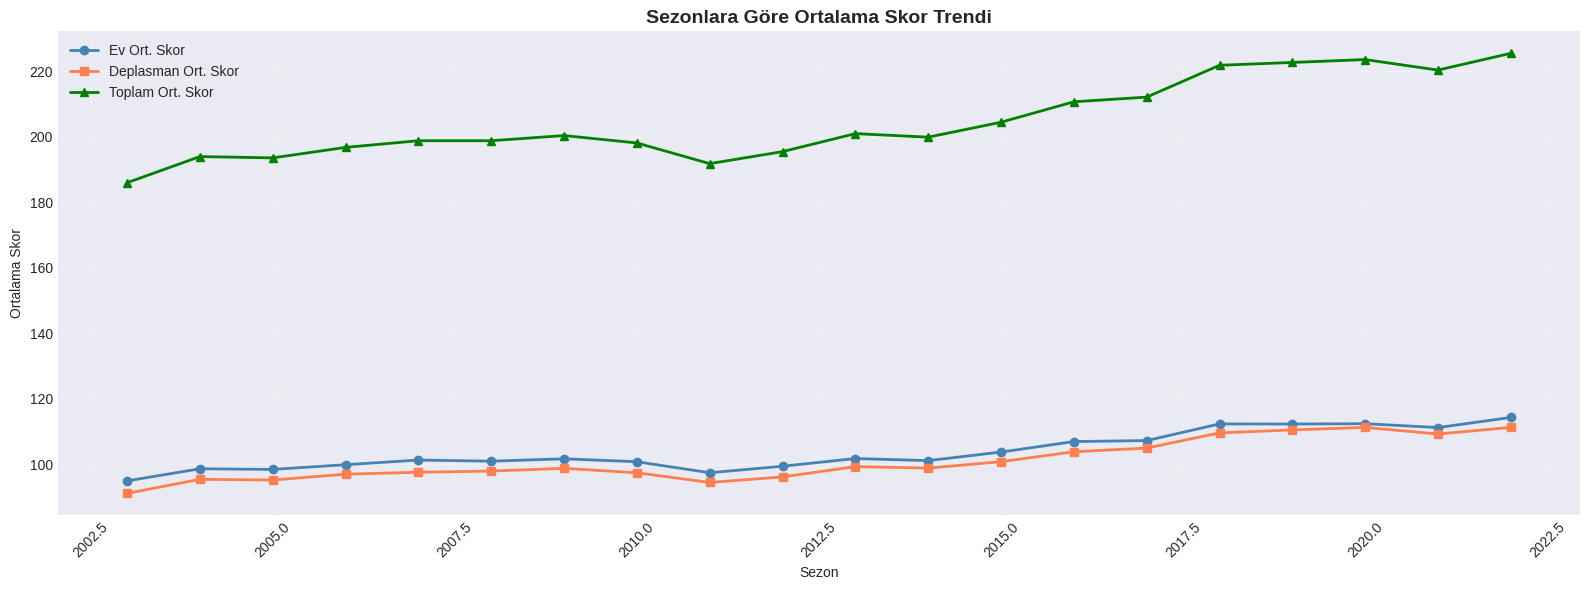

In [27]:
# Sezonlara göre trendler
if 'SEASON' in df.columns:
    season_stats = df.groupby('SEASON').agg({
        'GAME_ID': 'count',
        'PTS_home': 'mean',
        'PTS_away': 'mean' if 'PTS_away' in df.columns else 'count'
    }).rename(columns={'GAME_ID': 'Game_Count'})

    if 'PTS_away' in df.columns:
        season_stats['Avg_Total'] = season_stats['PTS_home'] + season_stats['PTS_away']

    print("\n" + "="*70)
    print("📈 SEZONLARA GÖRE İSTATİSTİKLER")
    print("="*70)
    print(season_stats)

    # Görselleştir
    fig, ax = plt.subplots(figsize=(16, 6))
    season_stats['PTS_home'].plot(ax=ax, marker='o', linewidth=2,
                                  label='Ev Ort. Skor', color='steelblue')
    if 'PTS_away' in df.columns:
        season_stats['PTS_away'].plot(ax=ax, marker='s', linewidth=2,
                                      label='Deplasman Ort. Skor', color='coral')
        season_stats['Avg_Total'].plot(ax=ax, marker='^', linewidth=2,
                                       label='Toplam Ort. Skor', color='green')
    ax.set_title('Sezonlara Göre Ortalama Skor Trendi',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Sezon')
    ax.set_ylabel('Ortalama Skor')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 📝 GAMES.CSV - Final Özet Raporu

In [28]:
# Kapsamlı özet rapor
print("\n" + "="*80)
print("📝 GAMES.CSV - KAPSAMLI ÖZET RAPOR")
print("="*80)

print(f"\n🎯 VERİ SETİ:")
print(f"  • Toplam Maç: {len(df):,}")
print(f"  • Sütun Sayısı: {len(df.columns)}")
print(f"  • Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'GAME_DATE_EST' in df.columns:
    print(f"\n📅 ZAMAN ARALIĞI:")
    print(f"  • İlk Maç: {df['GAME_DATE_EST'].min().strftime('%Y-%m-%d')}")
    print(f"  • Son Maç: {df['GAME_DATE_EST'].max().strftime('%Y-%m-%d')}")
    print(f"  • Süre: {(df['GAME_DATE_EST'].max() - df['GAME_DATE_EST'].min()).days:,} gün")

if 'Year' in df.columns:
    print(f"  • Yıllar: {df['Year'].min()} - {df['Year'].max()}")

if 'SEASON' in df.columns:
    print(f"  • Sezonlar: {df['SEASON'].min()} - {df['SEASON'].max()}")

if 'PTS_home' in df.columns:
    print(f"\n⛹️ SKOR İSTATİSTİKLERİ:")
    print(f"  • Ort. Ev Sahibi: {df['PTS_home'].mean():.2f}")
    if 'PTS_away' in df.columns:
        print(f"  • Ort. Deplasman: {df['PTS_away'].mean():.2f}")
        print(f"  • Ort. Toplam: {df['Total_Points'].mean():.2f}")
        print(f"  • Max Toplam: {df['Total_Points'].max():.0f}")
        print(f"  • Min Toplam: {df['Total_Points'].min():.0f}")

if 'HOME_TEAM_WINS' in df.columns:
    home_win_rate = (df['HOME_TEAM_WINS'].sum() / len(df)) * 100
    print(f"\n🏠 EV SAHİBİ AVANTAJI:")
    print(f"  • Kazanma Oranı: {home_win_rate:.2f}%")
    print(f"  • Avantaj: {home_win_rate - 50:.2f} puan")

if 'Score_Diff' in df.columns:
    close_5 = len(df[abs(df['Score_Diff']) <= 5])
    blowouts = len(df[abs(df['Score_Diff']) > 20])
    print(f"\n⚔️ MAÇ ÇEKİŞMESİ:")
    print(f"  • Çekişmeli (≤5): {(close_5/len(df)*100):.2f}%")
    print(f"  • Farklı (>20): {(blowouts/len(df)*100):.2f}%")

print(f"\n📊 VERİ KALİTESİ:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
print(f"  • Toplam Hücre: {total_cells:,}")
print(f"  • Eksik Hücre: {missing_cells:,}")
print(f"  • Eksiklik Oranı: {(missing_cells/total_cells*100):.2f}%")

print("\n" + "="*80)
print("✅ GAMES.CSV ANALİZİ TAMAMLANDI!")
print("="*80)
print("\n💡 Sonraki Adımlar:")
print("  • Diğer CSV dosyalarını analiz edin")
print("  • Maç sonucu tahmin modeli oluşturun")
print("  • Takım performans analizi yapın")
print("  • Feature engineering uygulayın")
print("\n" + "="*80)


📝 GAMES.CSV - KAPSAMLI ÖZET RAPOR

🎯 VERİ SETİ:
  • Toplam Maç: 26,651
  • Sütun Sayısı: 30
  • Bellek: 7.91 MB

📅 ZAMAN ARALIĞI:
  • İlk Maç: 2003-10-05
  • Son Maç: 2022-12-22
  • Süre: 7,018 gün
  • Yıllar: 2003 - 2022
  • Sezonlar: 2003 - 2022

⛹️ SKOR İSTATİSTİKLERİ:
  • Ort. Ev Sahibi: 103.46
  • Ort. Deplasman: 100.64
  • Ort. Toplam: 204.10
  • Max Toplam: 329
  • Min Toplam: 69

🏠 EV SAHİBİ AVANTAJI:
  • Kazanma Oranı: 58.70%
  • Avantaj: 8.70 puan

⚔️ MAÇ ÇEKİŞMESİ:
  • Çekişmeli (≤5): 27.53%
  • Farklı (>20): 13.11%

📊 VERİ KALİTESİ:
  • Toplam Hücre: 799,530
  • Eksik Hücre: 1,386
  • Eksiklik Oranı: 0.17%

✅ GAMES.CSV ANALİZİ TAMAMLANDI!

💡 Sonraki Adımlar:
  • Diğer CSV dosyalarını analiz edin
  • Maç sonucu tahmin modeli oluşturun
  • Takım performans analizi yapın
  • Feature engineering uygulayın

